In [1]:
project_name = 'brain_tumor_dataset_augmentation'

In [2]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"kapilmulay","key":"67f321788b03f9b0560a14f9ec11a7a7"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [4]:
!chmod 600 ~/.kaggle/kaggle.json


In [5]:
!pip install opendatasets --upgrade --quiet

In [6]:
import opendatasets as od

dataset1_url = 'https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor'
od.download(dataset1_url)

Dataset URL: https://www.kaggle.com/datasets/jakeshbohaju/brain-tumor


100%|██████████| 14.0M/14.0M [00:02<00:00, 6.45MB/s]


In [7]:
import os
import shutil

In [8]:
print(os.listdir('./brain-tumor/Brain Tumor/Brain Tumor')[:10])

['Image102.jpg', 'Image2219.jpg', 'Image3185.jpg', 'Image1100.jpg', 'Image1818.jpg', 'Image312.jpg', 'Image1328.jpg', 'Image1825.jpg', 'Image2596.jpg', 'Image185.jpg']


In [9]:
import pandas as pd
df = pd.read_csv('./brain-tumor/Brain Tumor.csv')
df.head()

,Image,Class,Mean,Variance,Standard Deviation,Entropy,Skewness,Kurtosis,Contrast,Energy,ASM,Homogeneity,Dissimilarity,Correlation,Coarseness
0,Image1,0,6.535339,619.587845,24.891522,0.109059,4.276477,18.900575,98.613971,0.293314,0.086033,0.530941,4.473346,0.981939,7.458341e-155
1,Image2,0,8.749969,805.957634,28.389393,0.266538,3.718116,14.464618,63.858816,0.475051,0.225674,0.651352,3.220072,0.988834,7.458341e-155
2,Image3,1,7.341095,1143.808219,33.820234,0.001467,5.061750,26.479563,81.867206,0.031917,0.001019,0.268275,5.981800,0.978014,7.458341e-155
3,Image4,1,5.958145,959.711985,30.979219,0.001477,5.677977,33.428845,151.229741,0.032024,0.001026,0.243851,7.700919,0.964189,7.458341e-155
4,Image5,0,7.315231,729.540579,27.010009,0.146761,4.283221,19.079108,174.988756,0.343849,0.118232,0.501140,6.834689,0.972789,7.458341e-155


In [10]:
filtered_df = df[df["Class"] == 1]
print(f'found {len(filtered_df)} tumor-positive images')

found 1683 tumor-positive images


In [11]:
os.makedirs('./tumor_positives', exist_ok=True)

In [12]:
copied = 0
missing = 0
for img_name in filtered_df["Image"]:
    src_path = os.path.join("./brain-tumor/Brain Tumor/Brain Tumor/", img_name+'.jpg')
    dest_path = os.path.join('./tumor_positives/')

    if os.path.exists(src_path):
        shutil.copy2(src_path, dest_path)
        copied += 1
    else:
        print(f"Missing: {img_name}")
        missing += 1

print(f"Copied: {copied}")
print(f"Missing: {missing}")

Copied: 1683
Missing: 0


In [13]:
dataset2_url = 'https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset'
od.download(dataset2_url)

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:07<00:00, 23.0MB/s]


In [14]:
import os
import shutil

def copy_all_images(src_dir, dest_dir):
    if not os.path.isdir(src_dir):
        raise ValueError(f"Source directory does not exist: {src_dir}")

    os.makedirs(dest_dir, exist_ok=True)

    copied = 0

    for file_name in os.listdir(src_dir):
          src_path = os.path.join(src_dir, file_name)
          dest_path = os.path.join(dest_dir, file_name)

          if os.path.isfile(src_path):
              shutil.copy2(src_path, dest_path)
              copied += 1

    print(f"Copied {copied} images from '{src_dir}' to '{dest_dir}'")


In [15]:
copy_all_images('./brain-tumor-mri-dataset/Training/glioma', './tumor_positives')
copy_all_images('./brain-tumor-mri-dataset/Training/meningioma', './tumor_positives')
copy_all_images('./brain-tumor-mri-dataset/Training/pituitary', './tumor_positives')

Copied 1400 images from './brain-tumor-mri-dataset/Training/glioma' to './tumor_positives'
Copied 1400 images from './brain-tumor-mri-dataset/Training/meningioma' to './tumor_positives'
Copied 1400 images from './brain-tumor-mri-dataset/Training/pituitary' to './tumor_positives'


In [16]:
copy_all_images('./brain-tumor-mri-dataset/Testing/glioma', './tumor_positives')
copy_all_images('./brain-tumor-mri-dataset/Testing/meningioma', './tumor_positives')
copy_all_images('./brain-tumor-mri-dataset/Testing/pituitary', './tumor_positives')

Copied 400 images from './brain-tumor-mri-dataset/Testing/glioma' to './tumor_positives'
Copied 400 images from './brain-tumor-mri-dataset/Testing/meningioma' to './tumor_positives'
Copied 400 images from './brain-tumor-mri-dataset/Testing/pituitary' to './tumor_positives'


In [17]:
dataset3_url = 'https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri'
od.download(dataset3_url)

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri


100%|██████████| 86.8M/86.8M [00:05<00:00, 16.9MB/s]


In [18]:
copy_all_images('./brain-tumor-classification-mri/Training/glioma_tumor', './tumor_positives')
copy_all_images('./brain-tumor-classification-mri/Training/meningioma_tumor', './tumor_positives')
copy_all_images('./brain-tumor-classification-mri/Training/pituitary_tumor', './tumor_positives')

Copied 826 images from './brain-tumor-classification-mri/Training/glioma_tumor' to './tumor_positives'
Copied 822 images from './brain-tumor-classification-mri/Training/meningioma_tumor' to './tumor_positives'
Copied 827 images from './brain-tumor-classification-mri/Training/pituitary_tumor' to './tumor_positives'


In [19]:
copy_all_images('./brain-tumor-classification-mri/Testing/glioma_tumor', './tumor_positives')
copy_all_images('./brain-tumor-classification-mri/Testing/meningioma_tumor', './tumor_positives')
copy_all_images('./brain-tumor-classification-mri/Testing/pituitary_tumor', './tumor_positives')

Copied 100 images from './brain-tumor-classification-mri/Testing/glioma_tumor' to './tumor_positives'
Copied 115 images from './brain-tumor-classification-mri/Testing/meningioma_tumor' to './tumor_positives'
Copied 74 images from './brain-tumor-classification-mri/Testing/pituitary_tumor' to './tumor_positives'


In [20]:
dataset4_url = 'https://www.kaggle.com/datasets/ahmedhamada0/brain-tumor-detection'
od.download(dataset4_url)

Dataset URL: https://www.kaggle.com/datasets/ahmedhamada0/brain-tumor-detection


100%|██████████| 84.0M/84.0M [00:05<00:00, 14.8MB/s]


In [21]:
copy_all_images('./brain-tumor-detection/yes', './tumor_positives')

Copied 1500 images from './brain-tumor-detection/yes' to './tumor_positives'


In [22]:
dataset5_url = 'https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection'
od.download(dataset5_url)

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection


100%|██████████| 15.1M/15.1M [00:01<00:00, 8.34MB/s]


In [23]:
copy_all_images('./brain-mri-images-for-brain-tumor-detection/yes', './tumor_positives')

Copied 155 images from './brain-mri-images-for-brain-tumor-detection/yes' to './tumor_positives'


In [24]:
print(f'aquired ', len(os.listdir('./tumor_positives')), 'tumor positive images')

aquired  11328 tumor positive images


In [25]:
os.makedirs('./tumors', exist_ok=True)

In [26]:
shutil.move('./tumor_positives', './tumors')

'./tumors/tumor_positives'

In [27]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as T

In [28]:
image_size = 64
batch_size = 128
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

In [29]:
train_ds = ImageFolder('./tumors', transform=T.Compose([
    T.Resize(image_size),
    T.CenterCrop(image_size),
    T.ToTensor(),
    T.Normalize(*stats)]))

train_dl = DataLoader(train_ds, batch_size, shuffle=True, num_workers=3, pin_memory=True)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [30]:
import torch
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
%matplotlib inline

In [31]:
def denorm(img_tensors):
    return img_tensors * stats[1][0] + stats[0][0]

In [32]:
def show_images(images, nmax=64):
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow=8).permute(1, 2, 0))

def show_batch(dl, nmax=64):
    for images, _ in dl:
        show_images(images, nmax)
        break

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


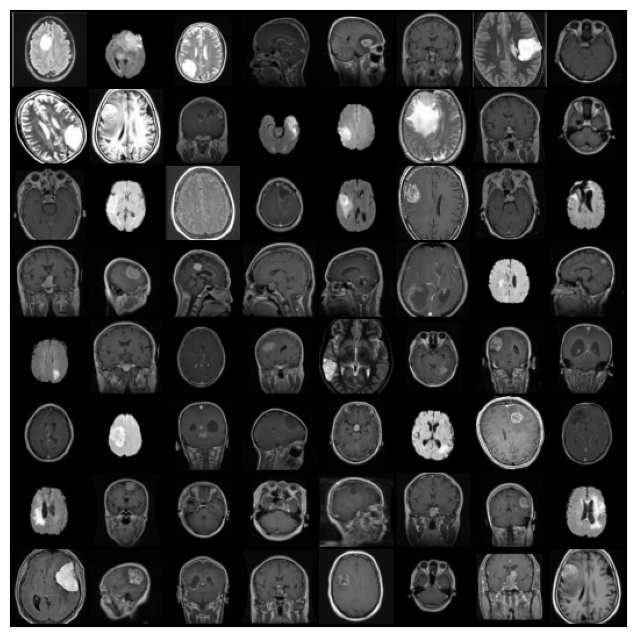

In [33]:
show_batch(train_dl)

In [34]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [35]:
device = get_default_device()
device

device(type='cuda')

In [36]:
train_dl = DeviceDataLoader(train_dl, device)

In [37]:
import torch.nn as nn

In [38]:
discriminator = nn.Sequential(
    # in: 3 x 64 x 64

    nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 64 x 32 x 32

    nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 128 x 16 x 16

    nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 256 x 8 x 8

    nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace=True),
    # out: 512 x 4 x 4

    nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
    # out: 1 x 1 x 1

    nn.Flatten(),
    nn.Sigmoid())

In [39]:
discriminator = to_device(discriminator, device)

In [40]:
latent_size = 128

In [41]:
generator = nn.Sequential(
    # in: latent_size x 1 x 1

    nn.ConvTranspose2d(latent_size, 512, kernel_size=4, stride=1, padding=0, bias=False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4

    nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8

    nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16

    nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32

    nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1, bias=False),
    nn.Tanh()
    # out: 3 x 64 x 64
)

torch.Size([128, 3, 64, 64])


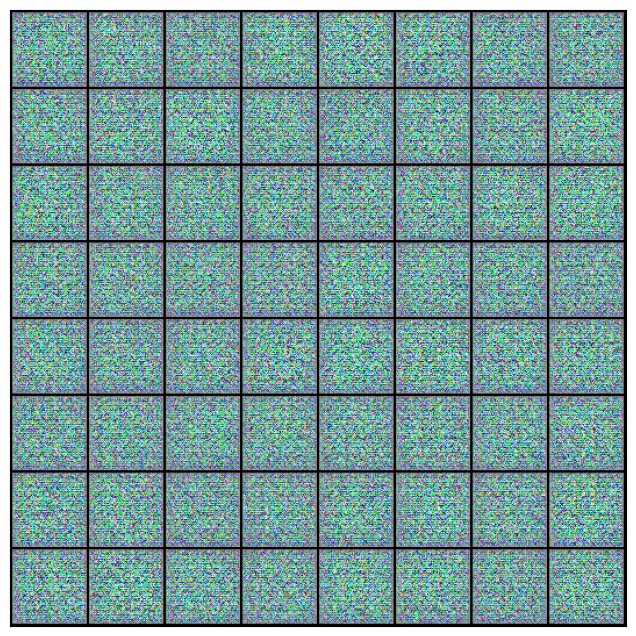

In [42]:
xb = torch.randn(batch_size, latent_size, 1, 1) # random latent tensors
fake_images = generator(xb)
print(fake_images.shape)
show_images(fake_images)

In [43]:
generator = to_device(generator, device)

In [44]:
def train_discriminator(real_images, opt_d):
    # Clear discriminator gradients
    opt_d.zero_grad()

    # Pass real images through discriminator
    real_preds = discriminator(real_images)
    real_targets = torch.ones(real_images.size(0), 1, device=device)
    real_loss = F.binary_cross_entropy(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()

    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)

    # Pass fake images through discriminator
    fake_targets = torch.zeros(fake_images.size(0), 1, device=device)
    fake_preds = discriminator(fake_images)
    fake_loss = F.binary_cross_entropy(fake_preds, fake_targets)
    fake_score = torch.mean(fake_preds).item()

    # Update discriminator weights
    loss = real_loss + fake_loss
    loss.backward()
    opt_d.step()
    return loss.item(), real_score, fake_score

In [45]:
def train_generator(opt_g):
    # Clear generator gradients
    opt_g.zero_grad()

    # Generate fake images
    latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
    fake_images = generator(latent)

    # Try to fool the discriminator
    preds = discriminator(fake_images)
    targets = torch.ones(batch_size, 1, device=device)
    loss = F.binary_cross_entropy(preds, targets)

    # Update generator weights
    loss.backward()
    opt_g.step()

    return loss.item()

In [46]:
from torchvision.utils import save_image

In [47]:
sample_dir = 'generated'
os.makedirs(sample_dir, exist_ok=True)

In [48]:
def save_samples(index, latent_tensors, show=True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow=8)
    print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(fake_images.cpu().detach(), nrow=8).permute(1, 2, 0))

In [49]:
fixed_latent = torch.randn(64, latent_size, 1, 1, device=device)

Saving generated-images-0000.png


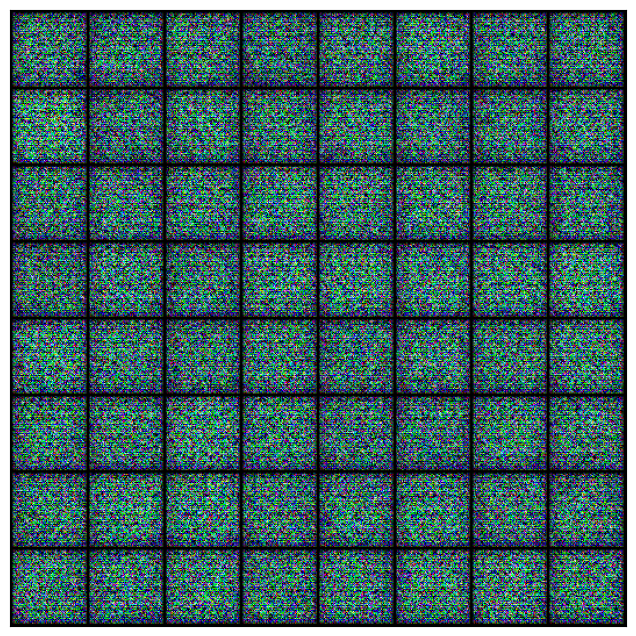

In [50]:
save_samples(0, fixed_latent)

In [51]:
from tqdm.notebook import tqdm
import torch.nn.functional as F

In [52]:
def fit(epochs, lr, start_idx=1):
    torch.cuda.empty_cache()

    # Losses & scores
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    # Create optimizers
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))

    for epoch in range(epochs):
        for real_images, _ in tqdm(train_dl):
            # Train discriminator
            loss_d, real_score, fake_score = train_discriminator(real_images, opt_d)
            # Train generator
            loss_g = train_generator(opt_g)

        # Record losses & scores
        losses_g.append(loss_g)
        losses_d.append(loss_d)
        real_scores.append(real_score)
        fake_scores.append(fake_score)

        # Log losses & scores (last batch)
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, loss_g, loss_d, real_score, fake_score))

        # Save generated images
        save_samples(epoch+start_idx, fixed_latent, show=True)

    return losses_g, losses_d, real_scores, fake_scores

In [53]:
lr = 0.0002
epochs = 100

In [ ]:
history = fit(epochs, lr)

In [55]:
from IPython.display import Image

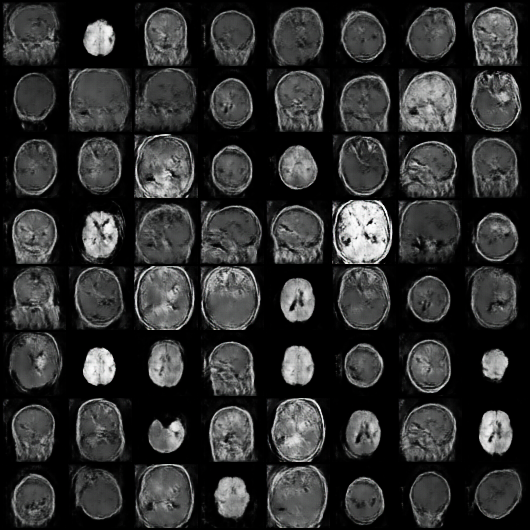

In [56]:
Image('generated/generated-images-0035.png')

### Calculate Frechet Inception Distance (FID)

FID is a metric used to assess the quality of images generated by a generative model, comparing the distribution of generated images to the distribution of real images.

In [57]:
!pip install clean-fid --quiet

In [ ]:
import os
import shutil
import torch
import torchvision.transforms as T
from torchvision.utils import save_image
from cleanfid import fid

# Number of images to generate for FID calculation
num_fid_images = 5000 

fid_gen_dir = './generated_for_fid'
os.makedirs(fid_gen_dir, exist_ok=True)

generator.eval()

print(f"Generating {num_fid_images} fake images for FID calculation...")

# Generate, denormalize and save fake images
with torch.no_grad():
    for i in range(num_fid_images // batch_size + 1):
        latent = torch.randn(batch_size, latent_size, 1, 1, device=device)
        fake_images = generator(latent)

        for j in range(fake_images.shape[0]):
            idx = i * batch_size + j
            if idx < num_fid_images:
                img_path = os.path.join(fid_gen_dir, f'fake_image_{idx:05d}.png')
                save_image(denorm(fake_images[j]), img_path)

print("Fake images generation complete. Calculating FID...")

# Calculate FID
# fdir1 is the directory containing real images
# fdir2 is the directory containing generated images
fid_score = fid.compute_fid(
    fdir1='./tumors',
    fdir2=fid_gen_dir,
    device=device,
    num_workers=os.cpu_count(), # Use all available CPU cores for loading
    mode='clean',
    verbose=True
)

print(f"\nFID Score: {fid_score:.2f}")

# Clean up the temporary directory
shutil.rmtree(fid_gen_dir)
print(f"Cleaned up temporary directory: {fid_gen_dir}")

Generating 5000 fake images for FID calculation...
Fake images generation complete. Calculating FID...
compute FID between two folders
Found 11328 images in the folder ./tumors


FID tumors : 100%|██████████| 354/354 [02:15<00:00,  2.61it/s]


Found 5000 images in the folder ./generated_for_fid


FID generated_for_fid : 100%|██████████| 157/157 [00:26<00:00,  5.83it/s]



FID Score: 139.55
Cleaned up temporary directory: ./generated_for_fid


### Latent Space Interpolation

We can visualize how the generator transitions between different generated images by interpolating between two random latent vectors. This helps to understand the continuity and smoothness of the learned latent space.

In [59]:
def slerp(t, z1, z2):
    z1_flat = z1.view(-1)
    z2_flat = z2.view(-1)

    z1_norm = z1_flat / z1_flat.norm()
    z2_norm = z2_flat / z2_flat.norm()

    omega = torch.acos(
        torch.clamp(torch.dot(z1_norm, z2_norm), -1.0, 1.0)
    )

    so = torch.sin(omega)

    if so < 1e-6:
        return (1 - t) * z1 + t * z2

    return (
        torch.sin((1 - t) * omega) / so * z1 +
        torch.sin(t * omega) / so * z2
    )

In [61]:
def interpolate(z1, z2, num_frames, use_slerp):
  method = "slerp" if use_slerp else "lerp"
  interpolation_dir = f'./interpolation_{method}'
  os.makedirs(interpolation_dir, exist_ok=True)
  print(f"Generating {num_frames} interpolation frames...")

  with torch.no_grad():
      for i in range(num_frames):
          alpha = i / (num_frames - 1)  # Alpha from 0 to 1
          z=z1
          if use_slerp:
              # Spherical Interpolation
              z = slerp(alpha, z1, z2)
          else:
              # Linear Interpolation
              z = (1 - alpha) * z1 + alpha * z2

          # Generate image from the interpolated latent vector
          interpolated_image = generator(z)

          # Save the image
          frame_fname = os.path.join(interpolation_dir, f'frame_{i:02d}.png')
          save_image(denorm(interpolated_image.cpu()), frame_fname)

  print("Interpolation frames generated successfully.")

In [71]:
import imageio.v2 as imageio
import os

def create_gif(folder_path, gif_filename='interpolation.gif', duration=0.1):
    """
    Generates a GIF from a sequence of images in a specified folder.

    Args:
        folder_path (str): The path to the folder containing the image frames.
        gif_filename (str): The name of the output GIF file.
        duration (float): The duration (in seconds) each frame is displayed.
    """
    images = []
    filenames = sorted([f for f in os.listdir(folder_path) if f.endswith('.png')])

    if not filenames:
        print(f"No PNG images found in '{folder_path}'.")
        return

    for filename in filenames:
        file_path = os.path.join(folder_path, filename)
        images.append(imageio.imread(file_path))

    output_path = os.path.join(folder_path, gif_filename)
    imageio.mimsave(output_path, images, duration=duration)
    print(f"GIF saved to: {output_path}")
    return output_path


In [116]:
# Define two random latent vectors
z1 = torch.randn(1, latent_size, 1, 1).to(device)
z2 = torch.randn(1, latent_size, 1, 1).to(device)

num_frames = 20

# Ensure generator is in evaluation mode
generator.eval()

interpolate(z1, z2, num_frames, True)
# interpolate(z1, z2, num_frames, False)

Generating 20 interpolation frames...
Interpolation frames generated successfully.


GIF saved to: ./interpolation_slerp/interpolation_slerp.gif


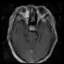

In [ ]:
output_gif_path = create_gif('./interpolation_slerp/', gif_filename='interpolation_slerp.gif', duration=0.2)

# Display the generated GIF
from IPython.display import Image, display
if output_gif_path and os.path.exists(output_gif_path):
    display(Image(filename=output_gif_path))

GIF saved to: ./interpolation_lerp/interpolation_lerp.gif


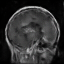

In [ ]:
output_gif_path = create_gif('./interpolation_lerp/', gif_filename='interpolation_lerp.gif', duration=0.2)

# Display the generated GIF
from IPython.display import Image, display
if output_gif_path and os.path.exists(output_gif_path):
    display(Image(filename=output_gif_path))

In [110]:
# Save the generator model
torch.save(generator.state_dict(), 'generator.pth')

# Save the discriminator model
torch.save(discriminator.state_dict(), 'discriminator.pth')

print('Generator and Discriminator models saved as generator.pth and discriminator.pth')

Generator and Discriminator models saved as generator.pth and discriminator.pth
